### This is the foundational code for scRNAseq of Isogenic Organoid Samples

In [51]:
import scanpy as sc


## Read in L1-L4 Libraries as anndata objects 
L1 = sc.read_10x_mtx("C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/L1/L1 Data",
                     var_names='gene_symbols', 
                     cache= True)
print(L1.shape)
L2 = sc.read_10x_mtx("C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/L2/L2 Data",
                     var_names='gene_symbols',
                     cache=True)
print(L2.shape)
L3 = sc.read_10x_mtx("C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/L3/L3 Data",
                     var_names='gene_symbols',
                     cache=True)
print(L3.shape)
L4 = sc.read_10x_mtx("C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/L4/Reanalyzed Data/L4 Data",
                     var_names='gene_symbols',
                     cache=True)
print(L4.shape)

(7642, 36601)
(6741, 36601)
(7320, 36601)
(7943, 36601)


In [52]:
L4.obs

""
AAACCCAAGACATACA-1
AAACCCAAGACCACGA-1
AAACCCAAGACCTCAT-1
AAACCCACACGGGCTT-1
AAACCCACACTAGGTT-1
...
TTTGTTGGTACGTACT-1
TTTGTTGGTAGCCAGA-1
TTTGTTGGTCCTGTCT-1
TTTGTTGGTTTGCAGT-1


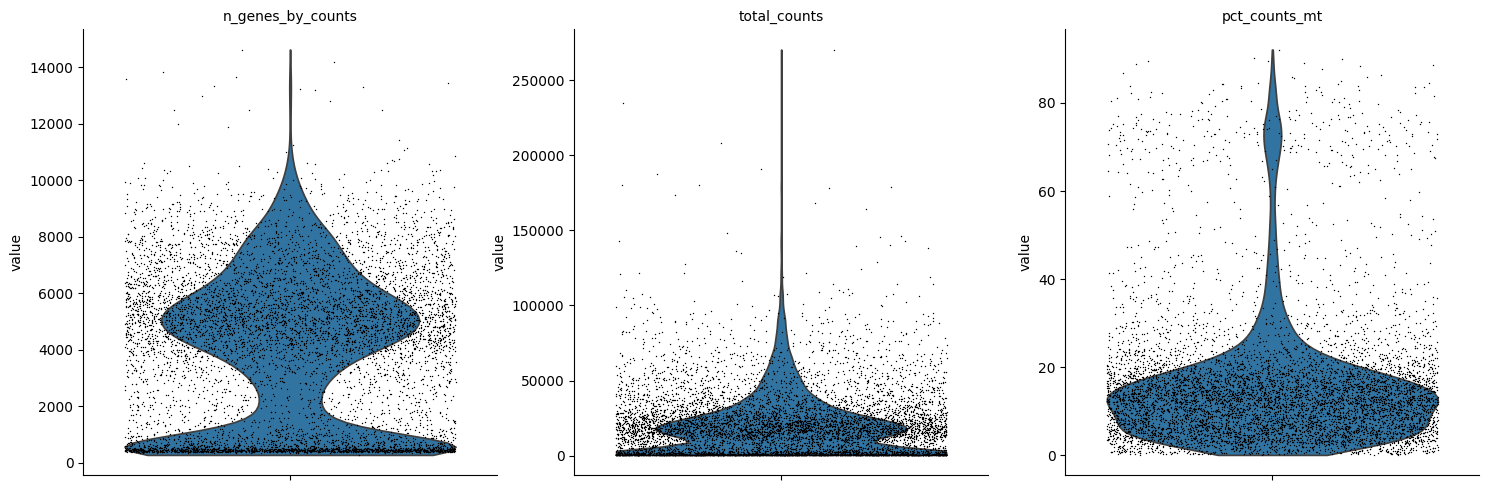

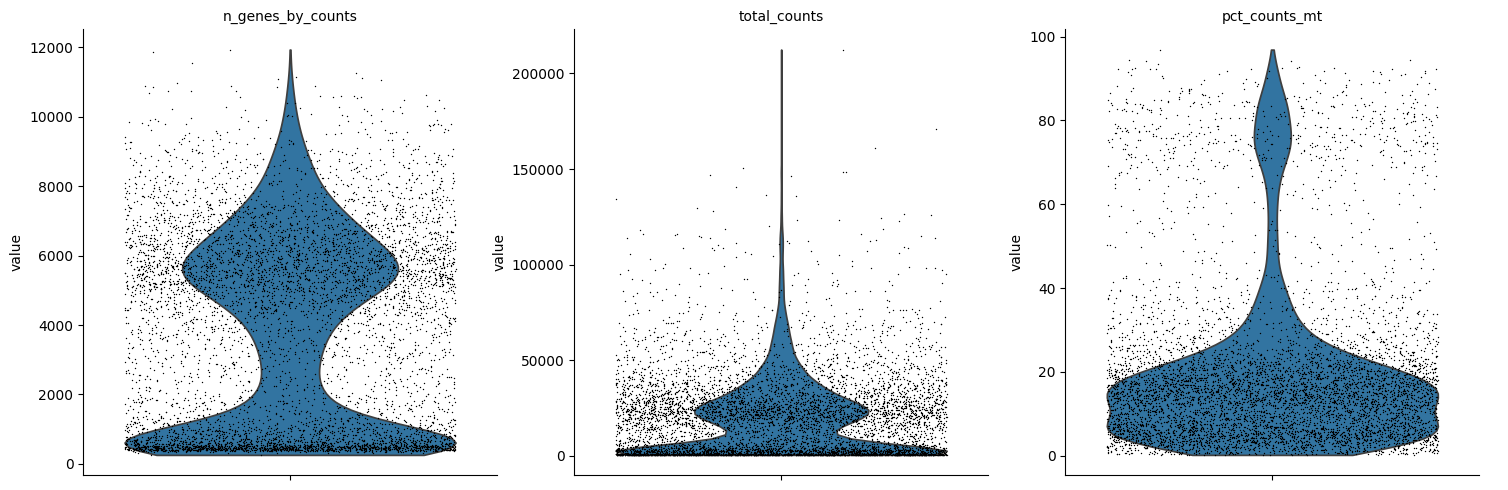

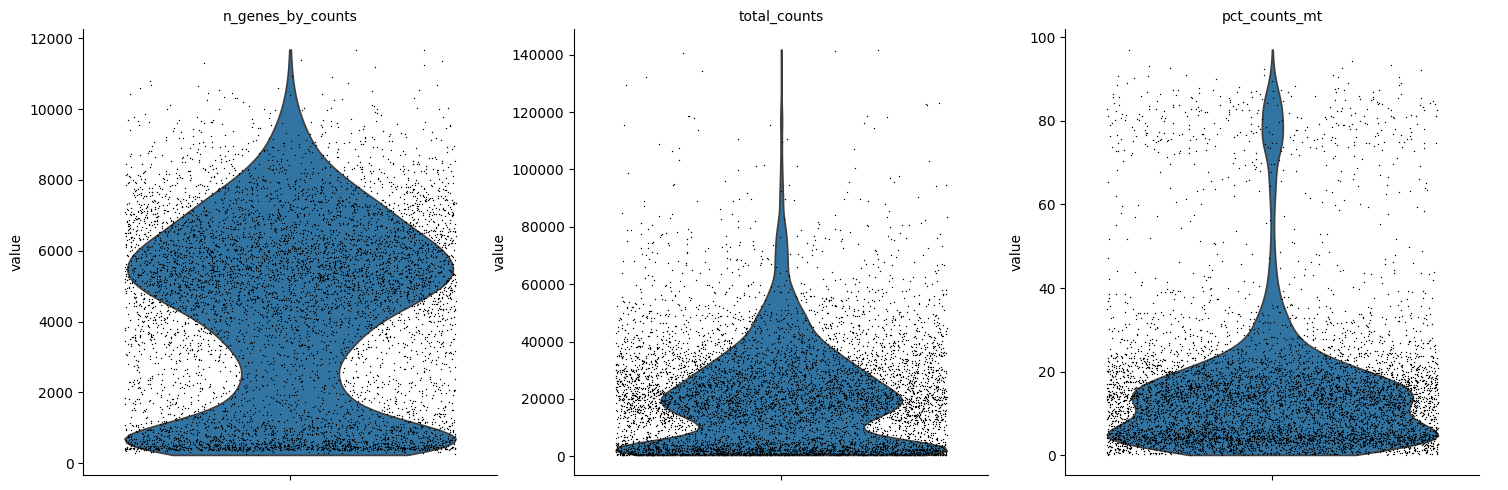

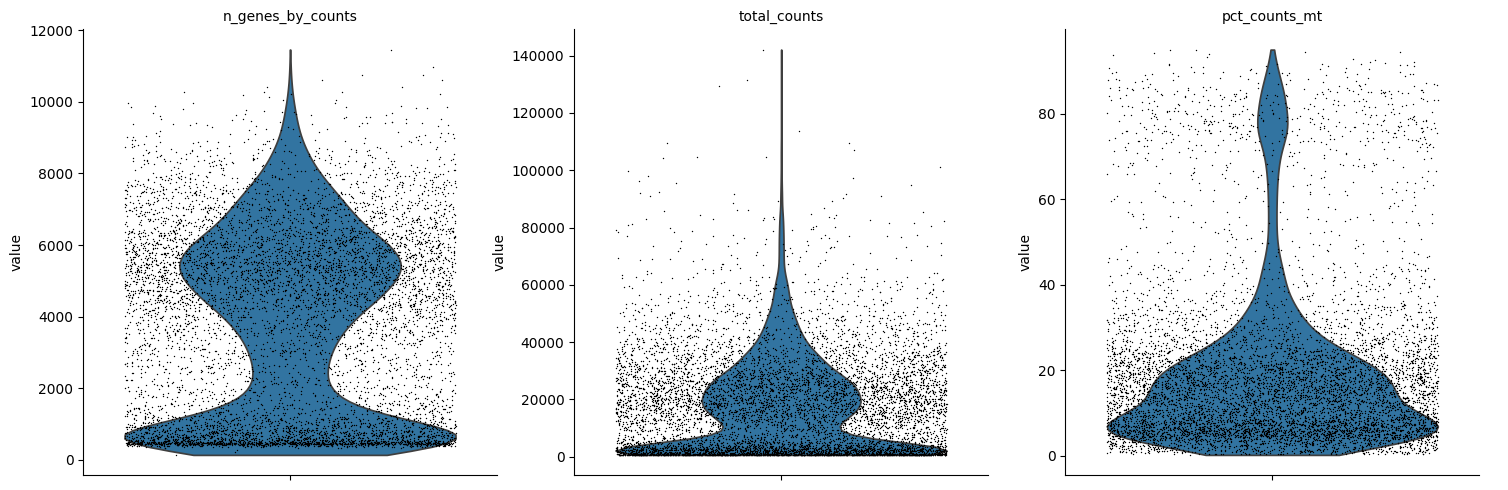

In [53]:
## Basic Preprocessing
#L1
sc.pp.filter_cells(L1, min_genes=200)
sc.pp.filter_genes(L1, min_cells=3)
#L2
sc.pp.filter_cells(L2, min_genes=200)
sc.pp.filter_genes(L2, min_cells=3)
#L3
sc.pp.filter_cells(L3, min_genes=200)
sc.pp.filter_genes(L3, min_cells=3)
#L4
L1.var['mt'] = L1.var_names.str.startswith('MT-')
L1.var[L1.var.mt == True]
sc.pp.calculate_qc_metrics(L1, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(L1, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

L2.var['mt'] = L2.var_names.str.startswith('MT-')
L2.var[L2.var.mt == True]
sc.pp.calculate_qc_metrics(L2, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(L2, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

L3.var['mt'] = L3.var_names.str.startswith('MT-')
L3.var[L3.var.mt == True]
sc.pp.calculate_qc_metrics(L3, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(L3, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)
L4.var['mt'] = L4.var_names.str.startswith('MT-')
L4.var[L4.var.mt == True]
sc.pp.calculate_qc_metrics(L4, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(L4, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

In [54]:
L1.var[L1.var.mt == True]

,gene_ids,feature_types,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
MT-ND1,ENSG00000198888,Gene Expression,7367,True,7367,130.213949,3.598534,995095.0
MT-ND2,ENSG00000198763,Gene Expression,7367,True,7367,142.480241,3.598534,1088834.0
MT-CO1,ENSG00000198804,Gene Expression,7623,True,7623,454.613714,0.248626,3474158.0
MT-CO2,ENSG00000198712,Gene Expression,7533,True,7533,251.499738,1.426328,1921961.0
MT-ATP8,ENSG00000228253,Gene Expression,6251,True,6251,17.482204,18.202041,133599.0
MT-ATP6,ENSG00000198899,Gene Expression,7630,True,7630,357.959696,0.157027,2735528.0
MT-CO3,ENSG00000198938,Gene Expression,7632,True,7632,435.728213,0.130856,3329835.0
MT-ND3,ENSG00000198840,Gene Expression,7609,True,7609,396.459827,0.431824,3029746.0
MT-ND4L,ENSG00000212907,Gene Expression,6185,True,6185,20.293640,19.065690,155084.0
MT-ND4,ENSG00000198886,Gene Expression,7467,True,7467,178.965192,2.289976,1367652.0


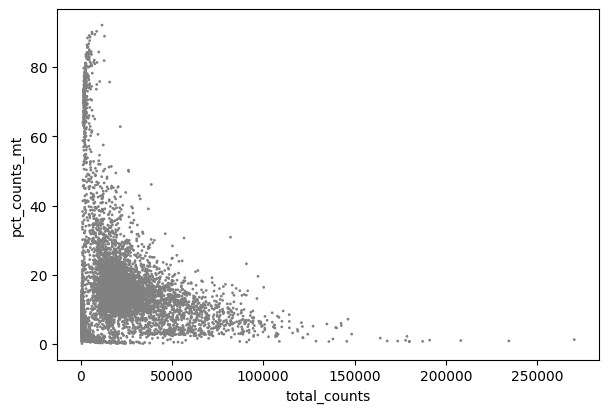

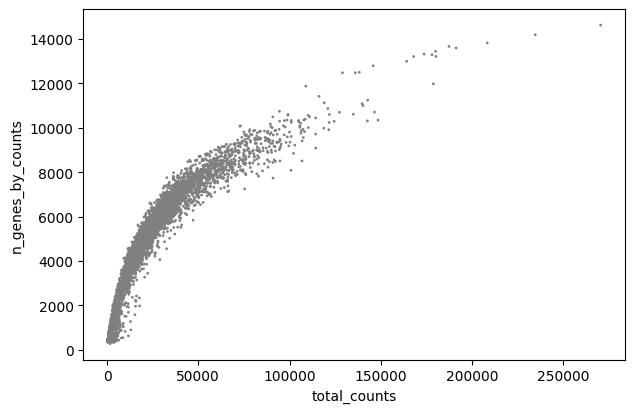

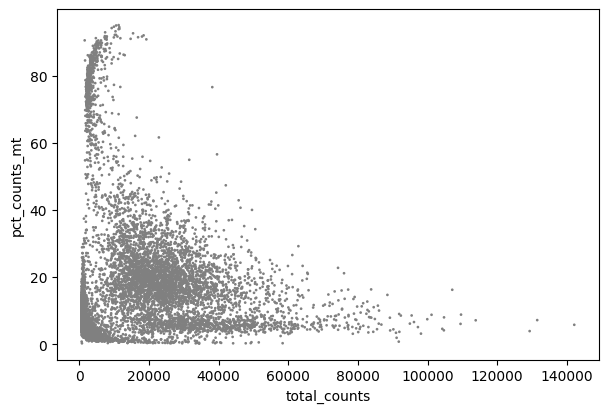

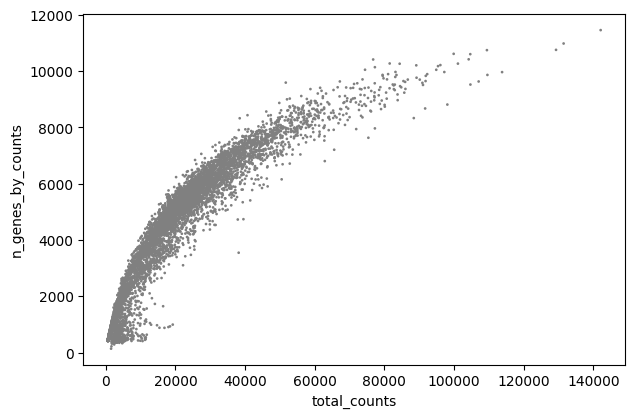

In [55]:
sc.pl.scatter(L1, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(L1, x='total_counts', y='n_genes_by_counts')
sc.pl.scatter(L4, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(L4, x='total_counts', y='n_genes_by_counts')

Data Preprocessing: Remove Doublets, cells, too low of RNA content, high mitochondrial content

In [56]:
import numpy as np
# For L1-L4: use quartile data to dictate cutoffs, rather than a semi-random look at the graph
#L1
upper_lim = np.quantile(L1.obs.n_genes_by_counts.values, .98)
lower_lim = np.quantile(L1.obs.n_genes_by_counts.values, .02)
print(f'{lower_lim} to {upper_lim}')
#L2
upper_lim2 = np.quantile(L2.obs.n_genes_by_counts.values, .98)
lower_lim2= np.quantile(L2.obs.n_genes_by_counts.values, .02)
print(f'{lower_lim2} to {upper_lim2}')
#L3
upper_lim3 = np.quantile(L3.obs.n_genes_by_counts.values, .98)
lower_lim3= np.quantile(L3.obs.n_genes_by_counts.values, .02)
print(f'{lower_lim3} to {upper_lim3}')
#L4
upper_lim4 = np.quantile(L4.obs.n_genes_by_counts.values, .98)
lower_lim4= np.quantile(L4.obs.n_genes_by_counts.values, .02)
print(f'{lower_lim4} to {upper_lim4}')
# Remove outliers in each individual object
L1 = L1[(L1.obs.n_genes_by_counts < upper_lim) & (L1.obs.n_genes_by_counts > lower_lim)]
L2 = L2[(L2.obs.n_genes_by_counts < upper_lim2) & (L2.obs.n_genes_by_counts > lower_lim2)]
L3 = L3[(L3.obs.n_genes_by_counts < upper_lim3) & (L3.obs.n_genes_by_counts > lower_lim3)]
L4 = L4[(L4.obs.n_genes_by_counts < upper_lim4) & (L4.obs.n_genes_by_counts > lower_lim4)]

391.0 to 9235.060000000005
388.8 to 9157.399999999998
394.38 to 9059.0
416.0 to 8596.64


Removing High Mitochondrial Content on a per object basis

In [57]:
# Again, let your data do the talking- my cutoff is high (25% mitochondrial RNA) but this is due to high mitochondrial presence within CMs, and by looking at our violin plots, we want to keep our threshold high here
L1 = L1[L1.obs.pct_counts_mt < 25]
L2 = L2[L2.obs.pct_counts_mt < 25]
L3 = L3[L3.obs.pct_counts_mt < 25]
L4 = L4[L4.obs.pct_counts_mt < 25]

Normalizing every cell to 10,000 UMI

In [58]:
sc.pp.normalize_total(L1, target_sum=1e4)
sc.pp.normalize_total(L2, target_sum=1e4)
sc.pp.normalize_total(L3, target_sum=1e4)
sc.pp.normalize_total(L4, target_sum=1e4)


C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scanpy\preprocessing\_normalization.py:208: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Adjust data to log counts (perform a log transformation)

In [59]:
sc.pp.log1p(L1)
sc.pp.log1p(L2)
sc.pp.log1p(L3)
sc.pp.log1p(L4)

Perform Clustering Analysis- this has a similar flavor as the Seurat Pipeline

In [60]:
sc.pp.highly_variable_genes(L1, min_mean = 0.0125, max_mean = 3, min_disp= 0.5) # Default Values
sc.pp.highly_variable_genes(L2, min_mean = 0.0125, max_mean = 3, min_disp= 0.5) # Default Values
sc.pp.highly_variable_genes(L3, min_mean = 0.0125, max_mean = 3, min_disp= 0.5) # Default Values
sc.pp.highly_variable_genes(L4, min_mean = 0.0125, max_mean = 3, min_disp= 0.5) # Default Values

In [61]:
# Check for your highly variable genes
L4.var[L4.var.highly_variable]
#
L1.raw = L1
L2.raw = L2
L3.raw = L3
L4.raw = L4

In [62]:
# Filter for the highly variable genes
L1 = L1[:, L1.var.highly_variable]
L2 = L2[:, L2.var.highly_variable]
L3 = L3[:, L3.var.highly_variable]
L4 = L4[:, L4.var.highly_variable]

In [63]:
# Regress out the effects of total counts per cell and and the percent mitochondrial RNA
# Via ChatGPT for more explanation: For each gene in the cell, Scanpy fits a linear model where the expression level of the gene is modeled as a function of the covariates 'total_counts' and 'pct_counts_mt' and removes those effects
sc.pp.regress_out(L1, ['total_counts', 'pct_counts_mt'])
sc.pp.regress_out(L2, ['total_counts', 'pct_counts_mt'])
sc.pp.regress_out(L3, ['total_counts', 'pct_counts_mt'])
sc.pp.regress_out(L4, ['total_counts', 'pct_counts_mt'])

C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scanpy\preprocessing\_simple.py:709: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scanpy\preprocessing\_simple.py:709: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scanpy\preprocessing\_simple.py:709: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scanpy\preprocessing\_simple.py:709: UserWarning: Received a view of an AnnData. Mak

In [64]:
# Scale each gene to unit variance
sc.pp.scale(L1, max_value=10)
sc.pp.scale(L2, max_value=10)
sc.pp.scale(L3, max_value=10)
sc.pp.scale(L4, max_value=10)

In [65]:
# Calculating PCA (just like in Seurat)
# To determine the number of PCs we want to use, plot them and see where they flatten out, usually 20 does the trick
sc.tl.pca(L1, svd_solver='arpack')
sc.tl.pca(L2, svd_solver='arpack')
sc.tl.pca(L3, svd_solver='arpack')
sc.tl.pca(L4, svd_solver='arpack')

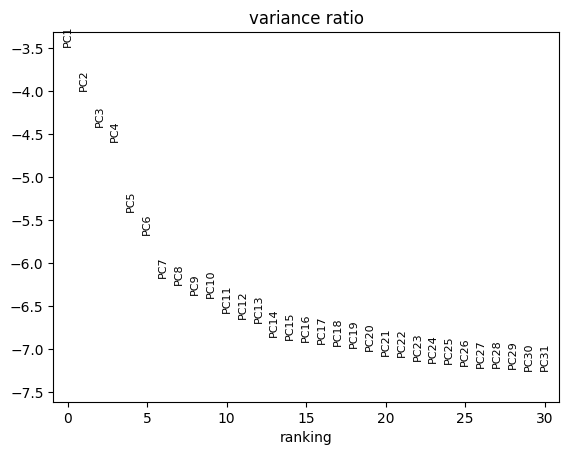

In [66]:
sc.pl.pca_variance_ratio(L1, log=True)

In [67]:
sc.pp.neighbors(L1, n_neighbors=10, n_pcs=20)
sc.pp.neighbors(L2, n_neighbors=10, n_pcs=20)
sc.pp.neighbors(L3, n_neighbors=10, n_pcs=20)
sc.pp.neighbors(L4, n_neighbors=10, n_pcs=20)

In [68]:
# Calculate and add in UMAP
sc.tl.umap(L1)
sc.tl.umap(L2)
sc.tl.umap(L3)
sc.tl.umap(L4)

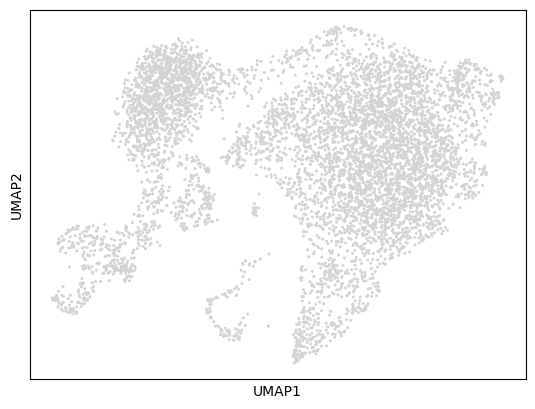

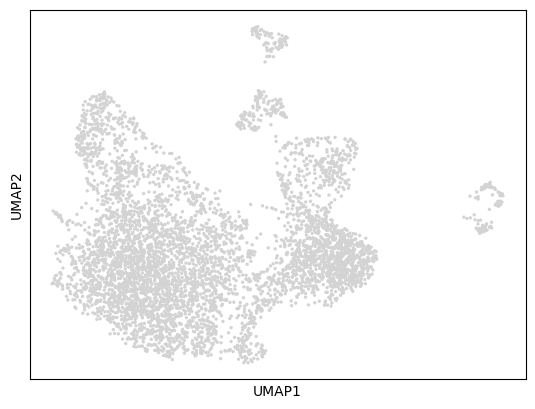

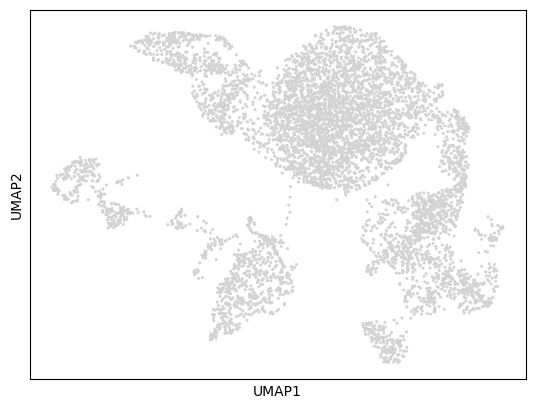

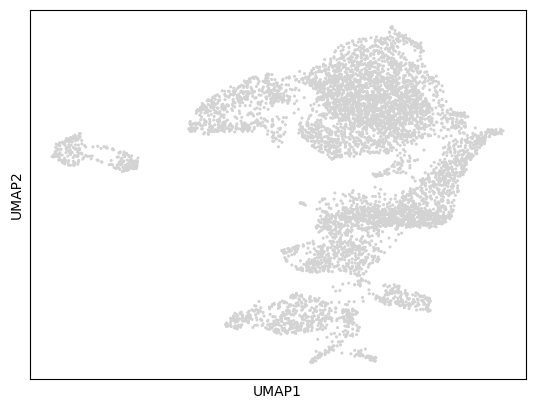

In [69]:
sc.pl.umap(L1)
sc.pl.umap(L2)
sc.pl.umap(L3)
sc.pl.umap(L4)

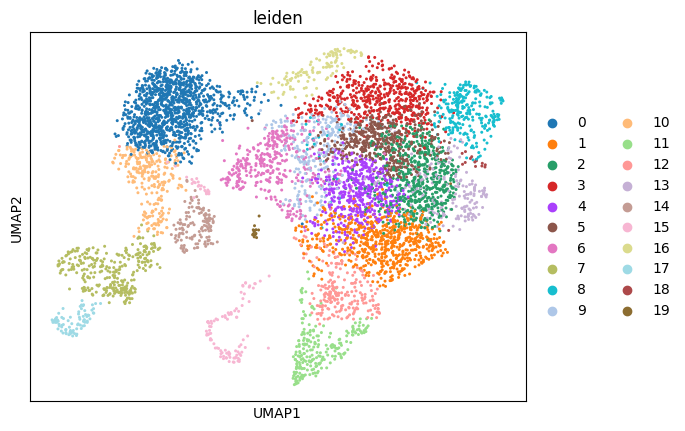

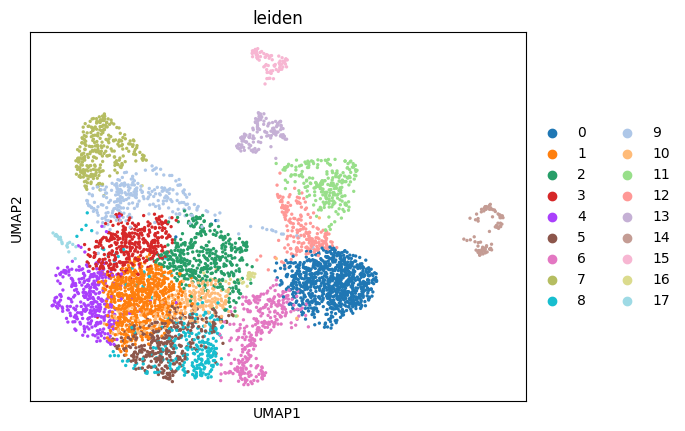

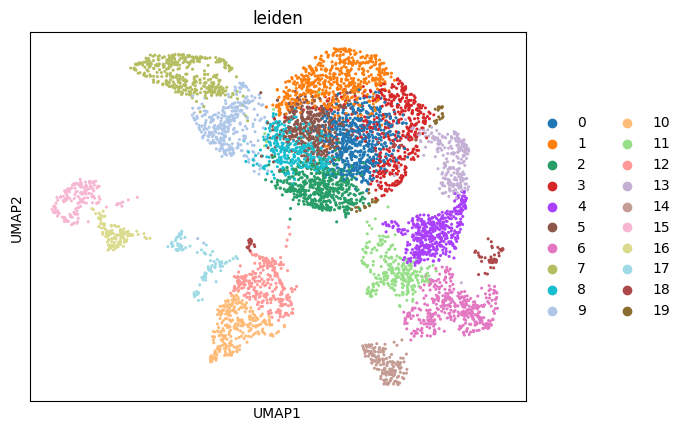

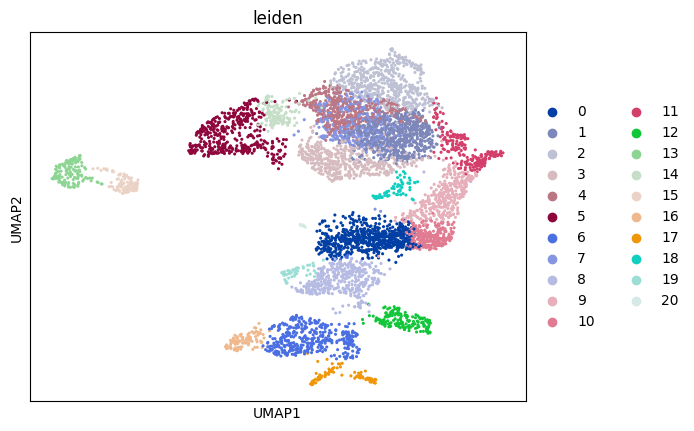

In [70]:
sc.tl.leiden(L1)
sc.pl.umap(L1, color=['leiden'])
sc.tl.leiden(L2)
sc.pl.umap(L2, color=['leiden'])
sc.tl.leiden(L3)
sc.pl.umap(L3, color=['leiden'])
sc.tl.leiden(L4)
sc.pl.umap(L4, color=['leiden'])


So now, we have all 4 objects preprocessed individually. The next step is to combine the four, and perform Harmony Integration

In [71]:
import anndata as ad

Organoids = ad.concat([L1, L2, L3, L4], label= 'batch', keys=['L1', 'L2', 'L3', 'L4'])
Organoids.obs['organoid_type'] = ['3 cell type' if batch in ['L1', 'L2'] else '4 cell type' 
                                   for batch in Organoids.obs['batch']]


C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [72]:
import harmonypy as hm
## Recompute PCA
sc.tl.pca(Organoids, svd_solver='arpack')

In [73]:
# Apply Harmony for batch correction using the 'batch' column in 'obs'
harmony_output = hm.run_harmony(Organoids.obsm['X_pca'], Organoids.obs, 'batch')

2025-03-10 21:02:45,051 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-03-10 21:02:51,884 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-03-10 21:02:52,072 - harmonypy - INFO - Iteration 1 of 10
2025-03-10 21:03:03,220 - harmonypy - INFO - Iteration 2 of 10
2025-03-10 21:03:14,594 - harmonypy - INFO - Iteration 3 of 10
2025-03-10 21:03:26,966 - harmonypy - INFO - Iteration 4 of 10
2025-03-10 21:03:38,113 - harmonypy - INFO - Iteration 5 of 10
2025-03-10 21:03:49,465 - harmonypy - INFO - Iteration 6 of 10
2025-03-10 21:03:54,447 - harmonypy - INFO - Iteration 7 of 10
2025-03-10 21:03:59,290 - harmonypy - INFO - Iteration 8 of 10
2025-03-10 21:04:03,708 - harmonypy - INFO - Iteration 9 of 10
2025-03-10 21:04:08,211 - harmonypy - INFO - Iteration 10 of 10
2025-03-10 21:04:12,677 - harmonypy - INFO - Converged after 10 iterations


In [74]:
# Update the PCA embeddings with the Harmony-corrected values
Organoids.obsm['X_pca_harmony'] = harmony_output.Z_corr.T

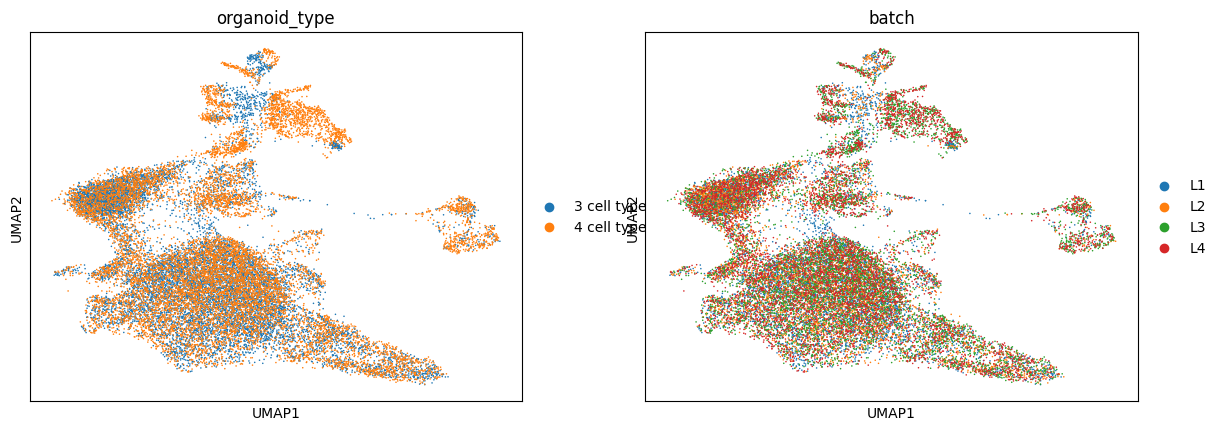

In [75]:
# Compute neighbors using the Harmony-corrected PCA
sc.pp.neighbors(Organoids, use_rep='X_pca_harmony')

# Generate UMAP
sc.tl.umap(Organoids)

# Plot UMAP colored by the cell type annotation
sc.pl.umap(Organoids, color=['organoid_type', 'batch'])


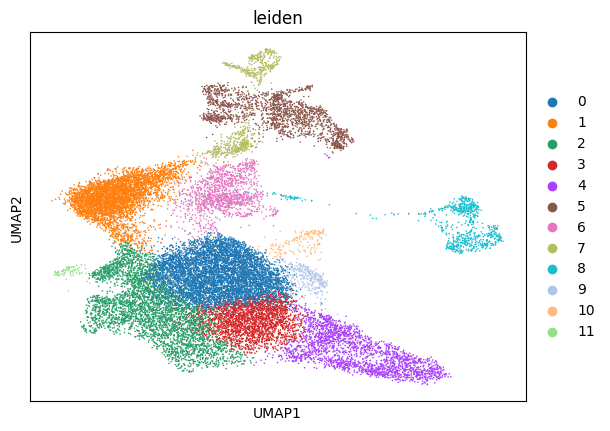

In [76]:
sc.tl.leiden(Organoids, resolution= 0.5)
sc.pl.umap(Organoids, color=['leiden'])

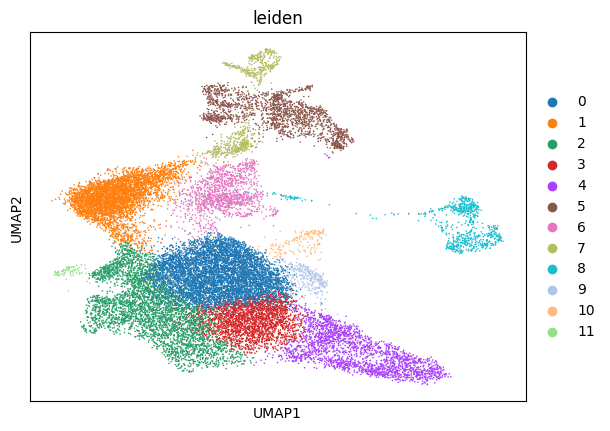

In [77]:
sc.pl.umap(Organoids, color=["leiden"])


In [78]:
# Removing the cell cycling cluster
cluster_to_remove = '7'
Organoids_filtered = Organoids[Organoids.obs['leiden'] != cluster_to_remove, :].copy()
print(Organoids_filtered.obs['leiden'].unique())


['2', '4', '0', '5', '3', ..., '6', '9', '8', '11', '10']
Length: 11
Categories (11, object): ['0', '1', '2', '3', ..., '8', '9', '10', '11']


C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


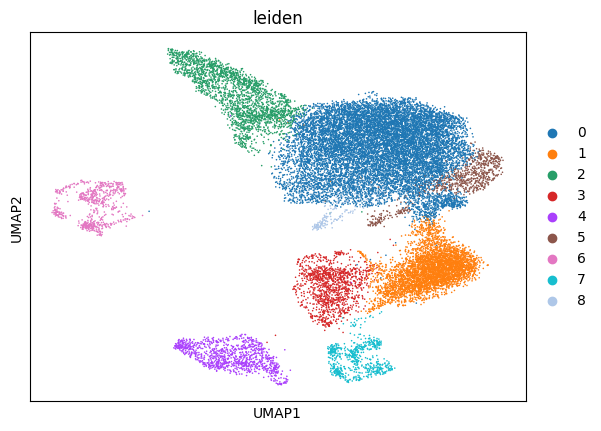

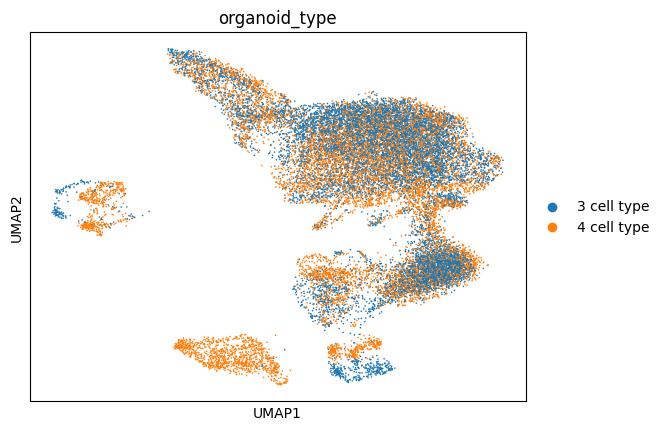

In [80]:
import scanpy as sc
sc.pp.neighbors(Organoids_filtered)
sc.tl.umap(Organoids_filtered)
sc.tl.leiden(Organoids_filtered, resolution = 0.3)
sc.pl.umap(Organoids_filtered, color=['leiden'])

shuffled_indices = np.random.permutation(Organoids_filtered.n_obs)
sc.pl.umap(Organoids_filtered[shuffled_indices], color=['organoid_type'], show=True)

Finding Markers

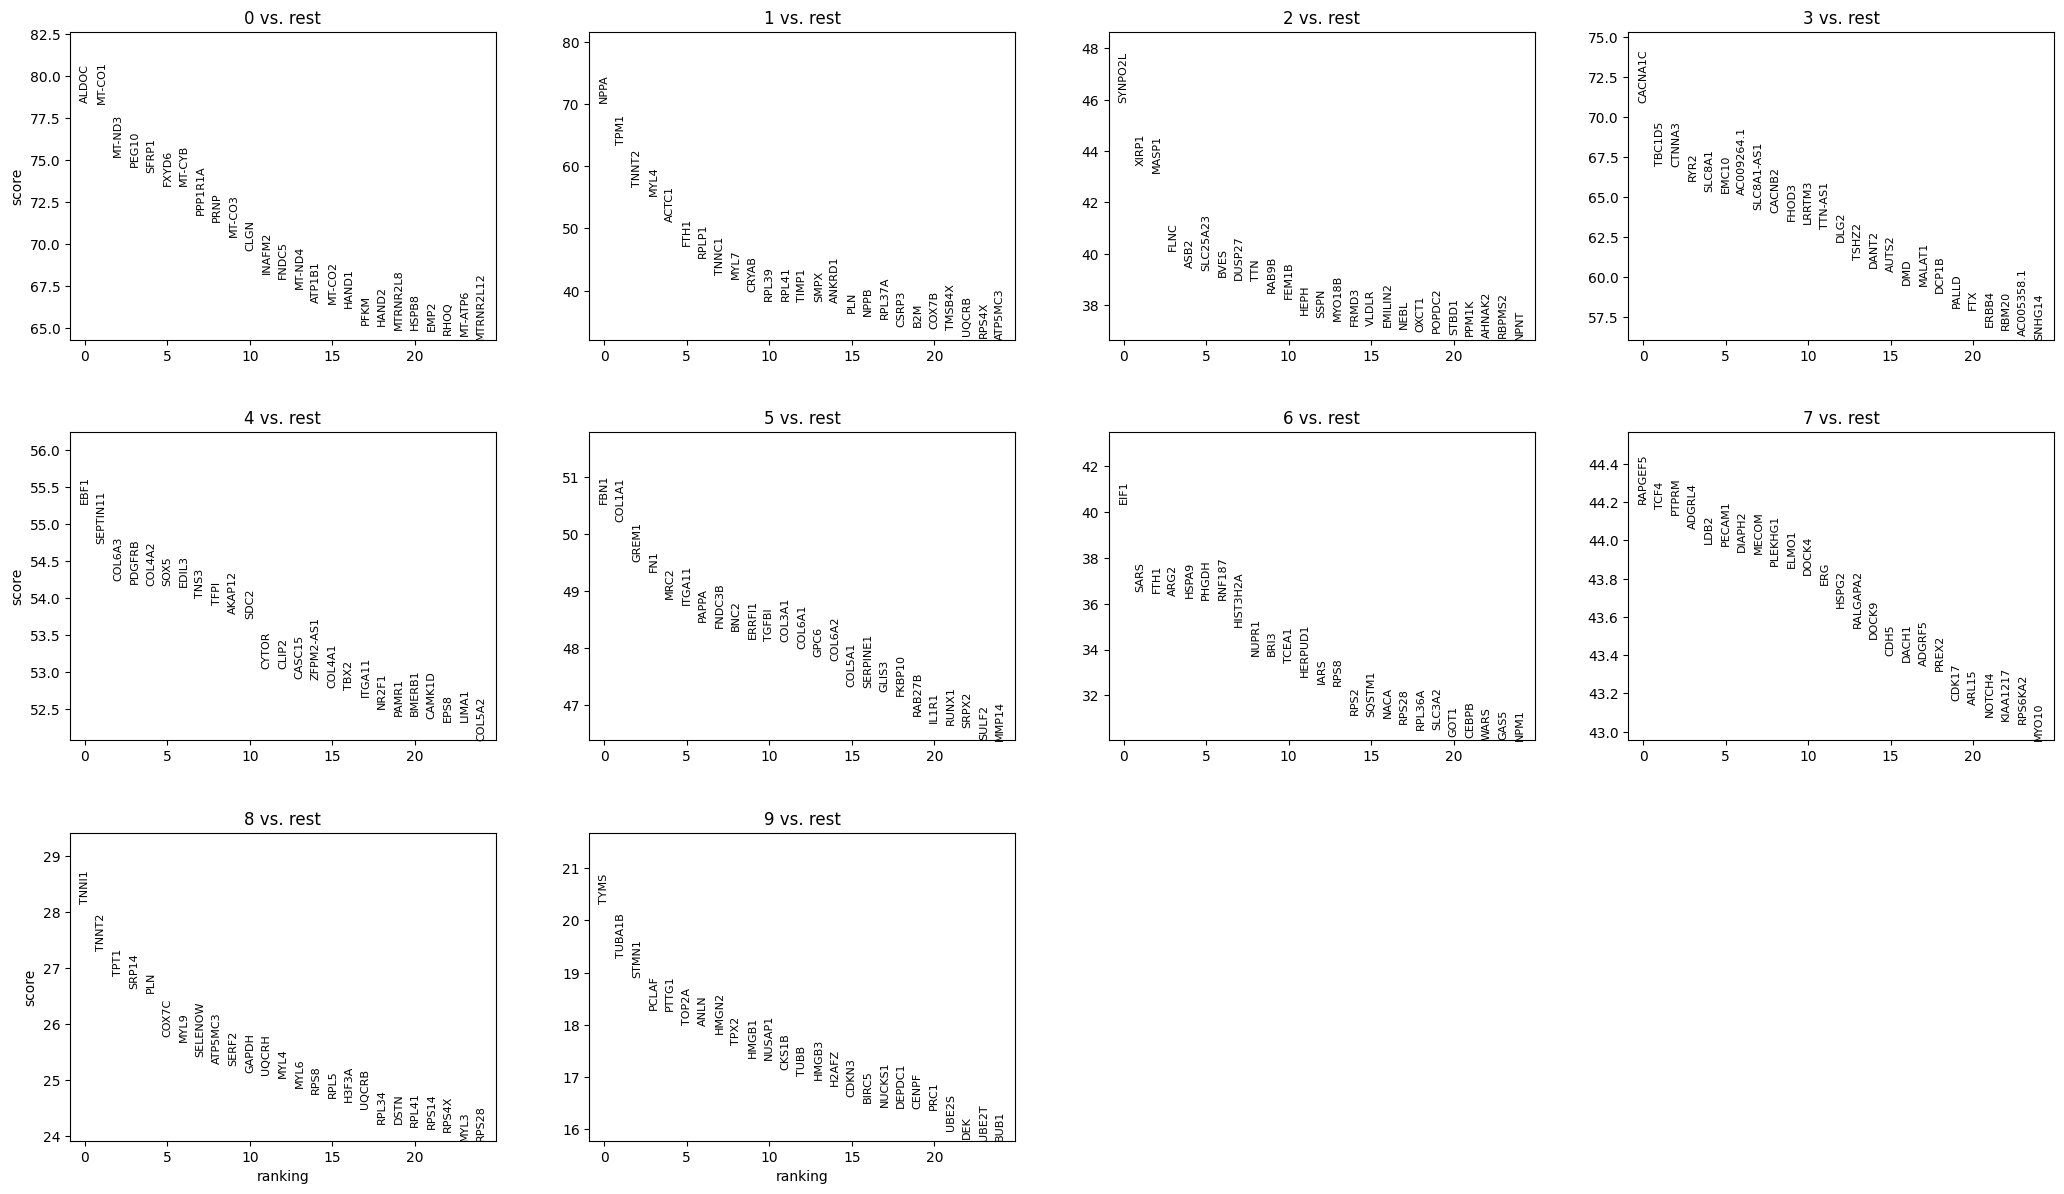

In [ ]:
sc.tl.rank_genes_groups(Organoids_filtered, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(Organoids_filtered, n_genes=25, sharey= False)

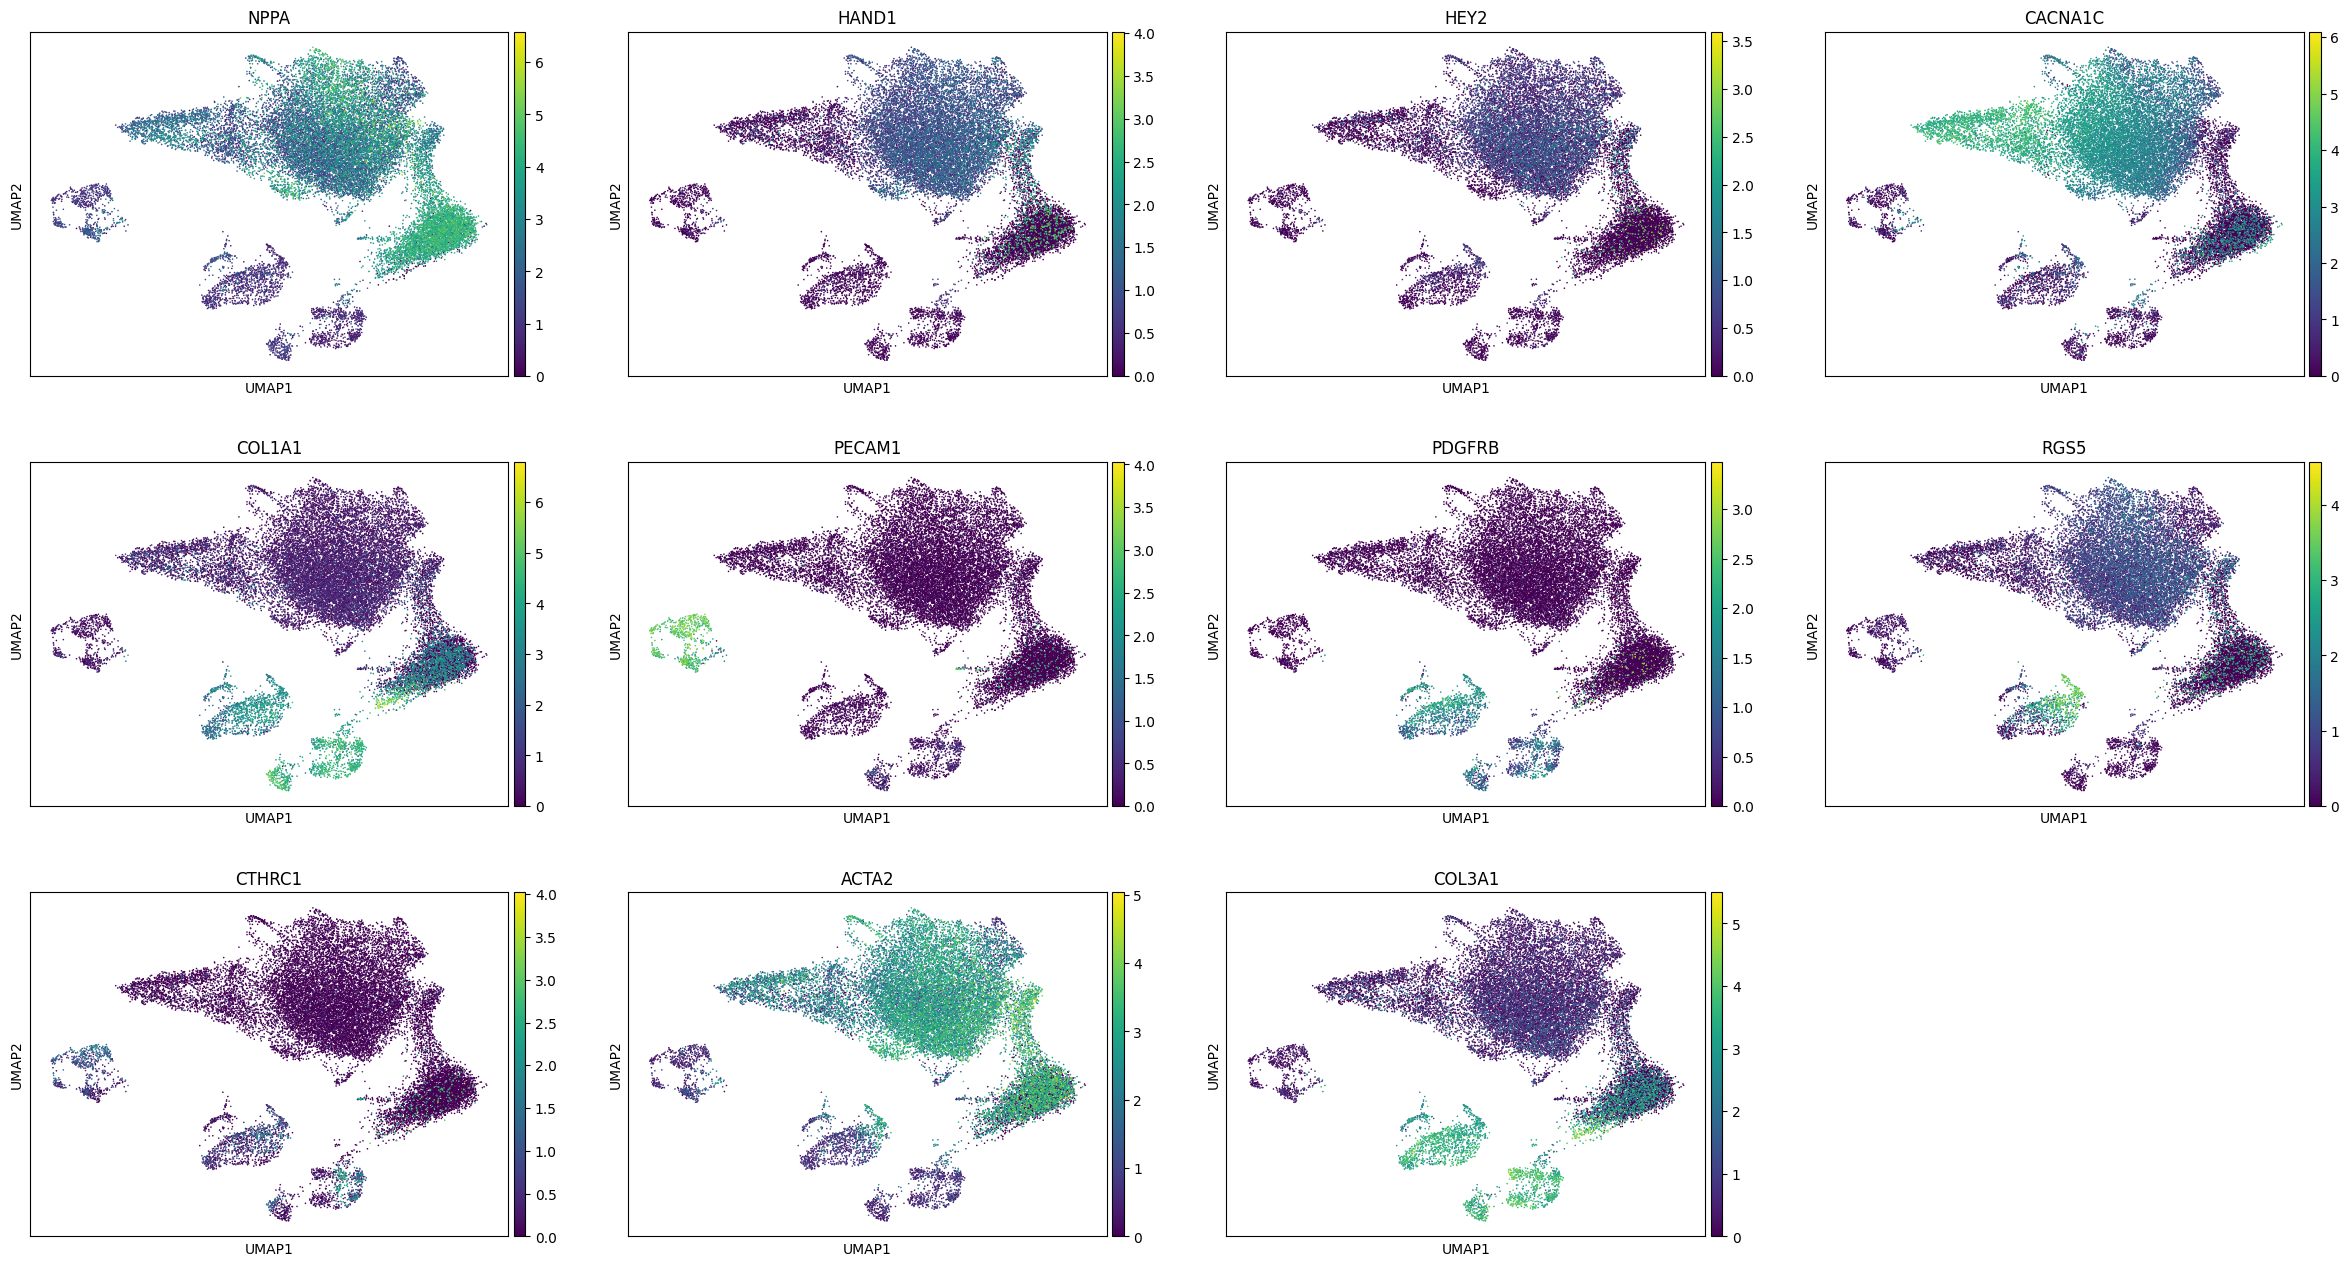

In [ ]:
## Showing features on top of UMAP plot

sc.pl.umap(Organoids_filtered, color=['NPPA','HAND1', 'HEY2', 'CACNA1C','COL1A1', 'PECAM1', 'PDGFRB', 'RGS5', 'CTHRC1', 'ACTA2', 'COL3A1'])

In [ ]:
# The gene names, p_vals, logfoldchange, etc can be accessed on a per cluster basis using these parameters
results = Organoids_filtered.uns['rank_genes_groups']

In [ ]:
results['names'].dtype.names

('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

In [ ]:
# Creating a dataframe consisting of our Marker Info
out = np.array([[0,0,0,0,0]])
for group in results['names'].dtype.names:
    out = np.vstack((out, np.vstack((results['names'][group],
                                     results['scores'][group],
                                     results['pvals_adj'][group],
                                     results['logfoldchanges'][group],
                                     np.array([group] * len(results['names'][group])).astype('object'))).T))

In [ ]:
import pandas as pd
markers = pd.DataFrame(out[1:], columns = ['Gene', 'scores', 'pval_adj', 'lfc', 'cluster'])

In [ ]:
markers

,Gene,scores,pval_adj,lfc,cluster
0,ALDOC,78.411674,0.0,1.929921,0
1,MT-CO1,78.369522,0.0,1.184824,0
2,MT-ND3,75.228943,0.0,1.280789,0
3,PEG10,74.620789,0.0,2.271693,0
4,SFRP1,74.272118,0.0,1.989581,0
...,...,...,...,...,...
258565,SLC25A4,-4.652638,0.000049,-0.192458,9
258566,MALAT1,-5.092236,0.000007,-0.607372,9
258567,TNNT2,-5.111694,0.000006,0.082985,9
258568,AREG,-5.252152,0.000003,-1.996188,9


In [ ]:
# Subsetting markers dataframe
markers[(markers.pval_adj < 0.05) & abs(markers.lfc > 1)]

,Gene,scores,pval_adj,lfc,cluster
0,ALDOC,78.411674,0.0,1.929921,0
1,MT-CO1,78.369522,0.0,1.184824,0
2,MT-ND3,75.228943,0.0,1.280789,0
3,PEG10,74.620789,0.0,2.271693,0
4,SFRP1,74.272118,0.0,1.989581,0
...,...,...,...,...,...
237581,DDX11,2.604913,0.048405,1.022612,9
237582,RASD2,2.603382,0.048612,1.226972,9
237594,CDAN1,2.59692,0.049411,1.163146,9
237595,CD3EAP,2.596878,0.049411,1.049018,9


In [ ]:
markers[markers.cluster == '0'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster0markers.csv', index=False)
markers[markers.cluster == '1'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster1markers.csv', index=False)
markers[markers.cluster == '2'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster2markers.csv', index=False)
markers[markers.cluster == '3'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster3markers.csv', index=False)
markers[markers.cluster == '4'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster4markers.csv', index=False)
markers[markers.cluster == '5'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster5markers.csv', index=False)
markers[markers.cluster == '6'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster6markers.csv', index=False)
markers[markers.cluster == '7'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster7markers.csv', index=False)
markers[markers.cluster == '8'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster8markers.csv', index=False)
markers[markers.cluster == '9'].to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Cluster9markers.csv', index=False)

In [81]:
# Renaming Clusters
new_cluster_names = {
    '0': 'Cardiomyocytes',
    '1': 'Cardiomyocytes',
    '2': 'Cardiomyocytes',
    '3': 'Cardiac Fibroblasts',
    '4': 'Pericytes',
    '5': 'Cardiomyocytes',
    '6': 'Endothelial Cells',
    '7': 'Cardiac Fibroblasts',
    '8': 'Cardiomyocytes',
    '9': 'Cardiomyocytes'  
}


In [82]:
Organoids_filtered.obs

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,batch,organoid_type
AAACCCAAGAGGACTC-1,6447,32182.0,5426.0,16.860357,5,L1,3 cell type
AAACCCAAGAGGCTGT-1,747,1020.0,54.0,5.294118,2,L1,3 cell type
AAACCCAAGCACTAAA-1,6485,29727.0,2509.0,8.440139,0,L1,3 cell type
AAACCCAAGGCCTGAA-1,7905,47075.0,1542.0,3.275624,7,L1,3 cell type
AAACCCACAACATCGT-1,5246,22619.0,3507.0,15.504664,0,L1,3 cell type
...,...,...,...,...,...,...,...
TTTGTTGCAACATCGT-1,2896,8287.0,83.0,1.001569,2,L4,4 cell type
TTTGTTGGTACGTACT-1,5559,22896.0,3515.0,15.352027,0,L4,4 cell type
TTTGTTGGTAGCCAGA-1,5551,22213.0,1574.0,7.085941,3,L4,4 cell type
TTTGTTGGTCCTGTCT-1,458,648.0,70.0,10.802469,1,L4,4 cell type


In [83]:
# Replace the cluster labels in the 'leiden' column with new names
Organoids_filtered.obs['cell_type'] = Organoids_filtered.obs['leiden'].map(new_cluster_names)



In [ ]:
# Save adata object as a .h5ad file
Organoids_filtered.write('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Integrated_Organoid_Object_filtered_simpleannotations.h5ad')


In [ ]:
Organoids_filtered.obs['cell_type'].values.describe()
Organoids_filtered.obs['organoid_type'].values.describe()

,counts,freqs
categories,,
3 cell type,11103,0.494522
4 cell type,11349,0.505478


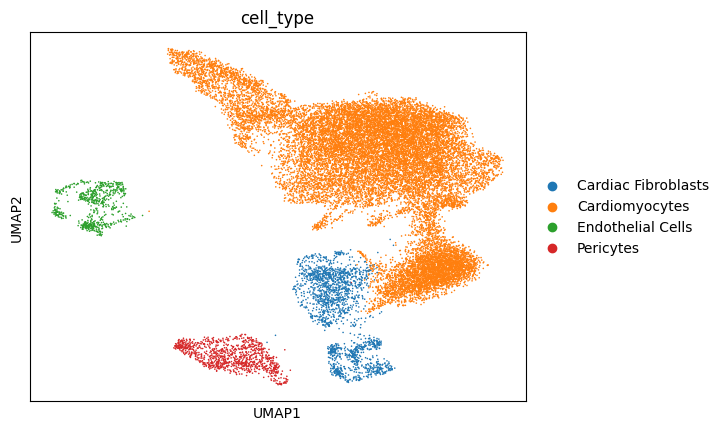

In [84]:
sc.pl.umap(Organoids_filtered, color=['cell_type'])

In [85]:
# Group by 'cell_type' and 'organoid_type' and get the size of each group
cell_type_freq = Organoids_filtered.obs.groupby(['cell_type', 'organoid_type']).size()

print(cell_type_freq)



cell_type            organoid_type
Cardiac Fibroblasts  3 cell type        801
                     4 cell type       1060
Cardiomyocytes       3 cell type      10432
                     4 cell type       8991
Endothelial Cells    3 cell type        173
                     4 cell type        502
Pericytes            3 cell type          6
                     4 cell type       1034
dtype: int64


C:\Users\nateh\AppData\Local\Temp\ipykernel_24056\4221654800.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_freq = Organoids_filtered.obs.groupby(['cell_type', 'organoid_type']).size()


Calculating and plotting the percent of each cell type for each organoid condition

C:\Users\nateh\AppData\Local\Temp\ipykernel_24056\3301782236.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_cells_per_organoid = cell_type_freq_df.groupby('organoid_type')['count'].transform('sum')


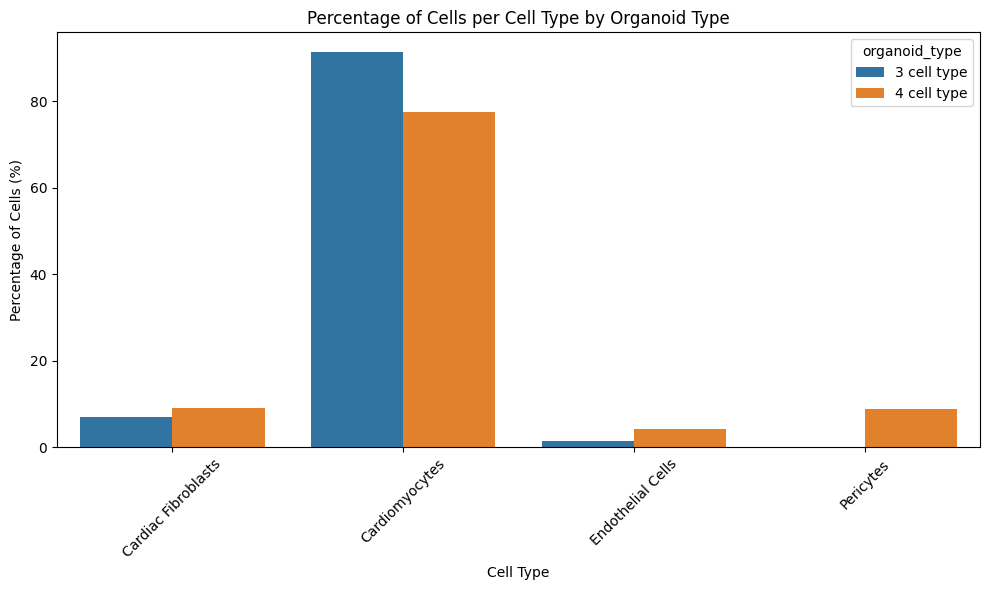

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert the cell_type_freq to a DataFrame for easier manipulation
cell_type_freq_df = cell_type_freq.reset_index(name='count')

# Step 2: Calculate the total number of cells for each organoid_type
total_cells_per_organoid = cell_type_freq_df.groupby('organoid_type')['count'].transform('sum')

# Step 3: Calculate the percentage of each cell_type within each organoid_type
cell_type_freq_df['percentage'] = (cell_type_freq_df['count'] / total_cells_per_organoid) * 100

# Step 4: Create a bar plot for percentages
plt.figure(figsize=(10, 6))
sns.barplot(data=cell_type_freq_df, x='cell_type', y='percentage', hue='organoid_type')

# Add labels and title
plt.xlabel('Cell Type')
plt.ylabel('Percentage of Cells (%)')
plt.title('Percentage of Cells per Cell Type by Organoid Type')

# Rotate the x-axis labels if needed
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


In [88]:
import marsilea as ma
import marsilea.plotter as mp

In [ ]:
Organoids_filtered

AnnData object with n_obs × n_vars = 22999 × 3797
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'batch', 'organoid_type', 'cell_type'
    uns: 'pca', 'neighbors', 'umap', 'organoid_type_colors', 'batch_colors', 'leiden', 'leiden_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [90]:
exp = Organoids_filtered[:,['cell_type']]

KeyError: "Values ['cell_type'], from ['cell_type'], are not valid obs/ var names or indices."

Taking a look at 3 cell type vs 4 cell type impacts on a cell type basis

In [ ]:
Organoids_filtered.obs.head()

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,batch,organoid_type,cell_type
AAACCCAAGAGGACTC-1,6447,32182.0,5426.0,16.860357,6,L1,3 cell type,Endothelial Cells
AAACCCAAGAGGCTGT-1,747,1020.0,54.0,5.294118,3,L1,3 cell type,Cardiomyocytes
AAACCCAAGCACTAAA-1,6485,29727.0,2509.0,8.440139,0,L1,3 cell type,Cardiomyocytes
AAACCCAAGGCCTGAA-1,7905,47075.0,1542.0,3.275624,5,L1,3 cell type,Pericytes
AAACCCACAACATCGT-1,5246,22619.0,3507.0,15.504664,0,L1,3 cell type,Cardiomyocytes


In [ ]:
ventricular_cms = 'Ventricular CMs 1'
Organoids_VCMs = Organoids_filtered[Organoids_filtered.obs['cell_type'] == ventricular_cms, :].copy()

In [ ]:
# Show how many cells in each condition for the specific cluster
Organoids_VCMs.obs['organoid_type'].value_counts()


Series([], Name: count, dtype: int64)

In [ ]:
# Perform differential expression analysis for the specific cluster
sc.tl.rank_genes_groups(Organoids_VCMs, groupby='organoid_type', method='wilcoxon')

# View the top differentially expressed genes
sc.pl.rank_genes_groups(Organoids_VCMs, n_genes=25, sharey=False)

Organoids_VCMs.obs.head()


ZeroDivisionError: integer division or modulo by zero

In [ ]:
VCM_DEGs = sc.get.rank_genes_groups_df(Organoids_VCMs, None)

# Define the thresholds for log fold change and adjusted p-value
logFC_threshold = 5  # For very high log fold changes
pval_adj_threshold = 0.0000000000000000001  # For highly significant adjusted p-values

# Subset the DataFrame based on these thresholds
VCM_DEGs_subset = VCM_DEGs[(VCM_DEGs['logfoldchanges'].abs() < logFC_threshold) & 
                           (VCM_DEGs['pvals_adj'] > pval_adj_threshold)]

# Display the first few rows of the subsetted DataFrame
VCM_DEGs_subset.head()



,group,names,scores,logfoldchanges,pvals,pvals_adj
366,3 cell type,PINK1,9.439122,0.282407,3.759141e-21,1.385207e-19
367,3 cell type,PRNP,9.420306,0.174260,4.497757e-21,1.654317e-19
368,3 cell type,CISD1,9.413018,0.149579,4.820912e-21,1.768146e-19
369,3 cell type,FAM32A,9.380385,0.340936,6.573195e-21,2.404004e-19
370,3 cell type,NOSIP,9.366634,0.362731,7.488211e-21,2.727080e-19


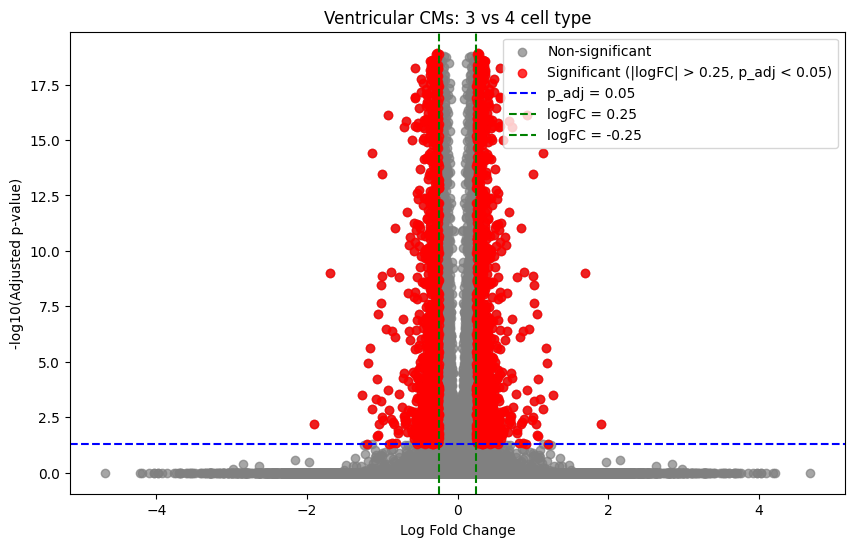

In [ ]:
import matplotlib.pyplot as plt

VCM_DEGs_subset = VCM_DEGs_subset.dropna(subset=['logfoldchanges', 'pvals_adj'])

# Add a column to mark significant genes
VCM_DEGs_subset['significant'] = (VCM_DEGs_subset['logfoldchanges'].abs() > 0.25) & (VCM_DEGs_subset['pvals_adj'] < 0.05)

# Create a new column for -log10(p-value) for the y-axis
VCM_DEGs_subset['-log10(pvals_adj)'] = -np.log10(VCM_DEGs_subset['pvals_adj'])

# Plot the volcano plot
plt.figure(figsize=(10, 6))

# Plot non-significant genes in gray
plt.scatter(VCM_DEGs_subset['logfoldchanges'], VCM_DEGs_subset['-log10(pvals_adj)'], 
            c='gray', label='Non-significant', alpha=0.7)

# Highlight significant genes in red
plt.scatter(VCM_DEGs_subset.loc[VCM_DEGs_subset['significant'], 'logfoldchanges'], 
            VCM_DEGs_subset.loc[VCM_DEGs_subset['significant'], '-log10(pvals_adj)'], 
            c='red', label='Significant (|logFC| > 0.25, p_adj < 0.05)', alpha=0.8)

# Add labels and title
plt.axhline(y=-np.log10(0.05), color='blue', linestyle='--', label='p_adj = 0.05')
plt.axvline(x=0.25, color='green', linestyle='--', label='logFC = 0.25')
plt.axvline(x=-0.25, color='green', linestyle='--', label='logFC = -0.25')

plt.xlabel('Log Fold Change')
plt.ylabel('-log10(Adjusted p-value)')
plt.title('Ventricular CMs: 3 vs 4 cell type')

# Add legend
plt.legend()

# Show the plot
plt.show()


In [ ]:

significant_genes = VCM_DEGs[(VCM_DEGs['pvals_adj'] < 0.05) & (VCM_DEGs['logfoldchanges'].abs() > 0.25)]
top_50_genes = significant_genes.nlargest(50, 'logfoldchanges')
print(top_50_genes)


             group       names     scores  logfoldchanges          pvals  \
27805  4 cell type        STC1   3.325591        1.911324   8.823116e-04   
26602  4 cell type      COL6A3   6.561975        1.688660   5.309995e-11   
25865  4 cell type        OOEP  23.954000        1.655463  8.394488e-127   
54     3 cell type  AL627171.2  23.515364        1.390784  2.840475e-122   
26163  4 cell type  AC007389.1   9.737556        1.279050   2.085074e-22   
1254   3 cell type  AC009878.2   4.153719        1.268598   3.271147e-05   
28267  4 cell type   LINC00670   2.637654        1.201811   8.348164e-03   
1030   3 cell type        RMRP   4.897485        1.188836   9.707121e-07   
946    3 cell type  AC132217.1   5.215511        1.168881   1.833109e-07   
25857  4 cell type    ADAMTSL1  34.383808        1.166309  4.402524e-259   
188    3 cell type   HIST2H2AC  13.841930        1.163723   1.423315e-43   
26320  4 cell type       SPRY4   8.264167        1.138120   1.406742e-16   
182    3 cel

In [ ]:
# Get the top 50 markers for each group (e.g., 'cell_type_1', 'cell_type_2', 'cell_type_3')
# Adjust the group names as per your actual data

top_50_3celltype = VCM_DEGs[VCM_DEGs['3 cell type'] == 'cell_type_1'].nlargest(50, 'logfoldchanges')
top_50_4celltype = VCM_DEGs[VCM_DEGs['4 cell type'] == 'cell_type_2'].nlargest(50, 'logfoldchanges')
top_50_cell_type_3 = VCM_DEGs[VCM_DEGs['group'] == 'cell_type_3'].nlargest(50, 'logfoldchanges')
top_50_cell_type_4 = VCM_DEGs[VCM_DEGs['group'] == 'cell_type_4'].nlargest(50, 'logfoldchanges')  # Optional

# Combine these into a single list of gene names
top_genes_to_label = pd.concat([top_50_cell_type_1, top_50_cell_type_2, top_50_cell_type_3, top_50_cell_type_4])['names'].unique()


KeyError: '3 cell type'